<div align=center>

---
# Noise response
---

</div>


## Noise sensitivity

In [ ]:
import noise_sensitivity
import phise
import astropy.units as u
import numpy as np
ctx = phise.examples.contexts.get_VLTI()
ctx.monochromatic = True
ctx.Γ = 10 * u.nm
noise_sensitivity.plot(ctx=ctx, β=0.961, n=1_000, γ=10*u.nm, figsize=(6, 3), save_as="generated/thesis/noise_sensitivity.png")

---

<div align=center>

# ?? **Data generation**

</div>

First, let's generate the different scenes we will compare:

Done! Plotting results...


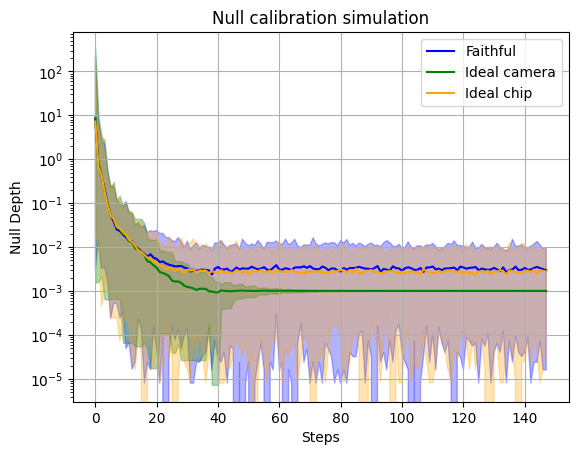

In [9]:
import phise
import numpy as np
from copy import deepcopy as copy

ctx_real = phise.examples.contexts.get_PHOB()

λ = ctx_real.interferometer.λ

ctx_cam = copy(ctx_real)
ctx_cam.camera.ideal = True
ctx_both = copy(ctx_cam)
ctx_both.chip = phise.classes.archs.N4x4_T8_Ideal(
                φ = np.zeros(4) * λ, # Injected phase shifts
                σ = ctx_real.chip.σ, # Manufacturing OPD errors
                λ0 = λ,
                name = "N4x4-T8 ideal", # Kernel nuller name
            )
ctx_chip = copy(ctx_both)
ctx_chip.camera.ideal = False

N = 100
data_real = []
data_cam = []
data_chip = []
data_both = []
for i in range(N):
    print(f"Iteration {i+1}/{N}", end="\r")
    σ = np.random.normal(0, 1, 4) * λ

    ctx_real.chip.σ = σ
    ctx_cam.chip.σ = σ
    ctx_both.chip.σ = σ
    ctx_chip.chip.σ = σ

    real = phise.calibration.trialerror.calibrate_gen(ctx=ctx_real, β=0.7)
    cam = phise.calibration.trialerror.calibrate_gen(ctx=ctx_cam, β=0.7)
    chip = phise.calibration.trialerror.calibrate_gen(ctx=ctx_chip, β=0.7)
    both = phise.calibration.trialerror.calibrate_gen(ctx=ctx_both, β=0.7)

    data_real.append(real['depth'])
    data_cam.append(cam['depth'])
    data_chip.append(chip['depth'])
    data_both.append(both['depth'])

print("Done! Plotting results...")

data_real = np.array(data_real)
data_cam = np.array(data_cam)
data_chip = np.array(data_chip)
data_both = np.array(data_both)

data_real_max = np.max(data_real, axis=0)
data_cam_max = np.max(data_cam, axis=0)
data_chip_max = np.max(data_chip, axis=0)
data_both_max = np.max(data_both, axis=0)

data_real_min = np.min(data_real, axis=0)
data_cam_min = np.min(data_cam, axis=0)
data_chip_min = np.min(data_chip, axis=0)
data_both_min = np.min(data_both, axis=0)

data_real_mean = np.mean(data_real, axis=0)
data_cam_mean = np.mean(data_cam, axis=0)
data_chip_mean = np.mean(data_chip, axis=0)
data_both_mean = np.mean(data_both, axis=0)

x_axis = np.arange(data_real_mean.shape[0])

# Filled plot for the range of values
import matplotlib.pyplot as plt
plt.fill_between(x_axis, data_real_min, data_real_max, color='blue', alpha=0.3)
plt.fill_between(x_axis, data_cam_min, data_cam_max, color='green', alpha=0.3)
plt.fill_between(x_axis, data_chip_min, data_chip_max, color='orange', alpha=0.3)
# plt.fill_between(x_axis, data_both_min, data_both_max, color='red', alpha=0.3)

plt.plot(x_axis, data_real_mean, color='blue', label='Faithful')
plt.plot(x_axis, data_cam_mean, color='green', label='Ideal camera')
plt.plot(x_axis, data_chip_mean, color='orange', label='Ideal chip')
# plt.plot(x_axis, data_both_mean, color='red', label='Ideal chip & camera')

plt.title("Null calibration simulation")
plt.ylabel('Null Depth')
plt.yscale('log')
plt.xlabel('Steps')
plt.grid()
plt.legend()
plt.show()

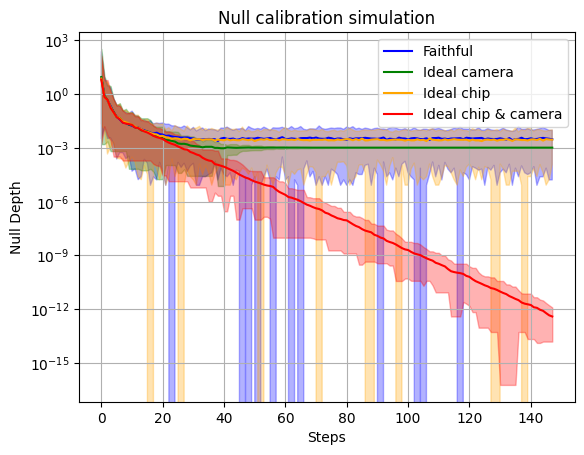

In [10]:
# Filled plot for the range of values
import matplotlib.pyplot as plt
plt.fill_between(x_axis, data_real_min, data_real_max, color='blue', alpha=0.3)
plt.fill_between(x_axis, data_cam_min, data_cam_max, color='green', alpha=0.3)
plt.fill_between(x_axis, data_chip_min, data_chip_max, color='orange', alpha=0.3)
plt.fill_between(x_axis, data_both_min, data_both_max, color='red', alpha=0.3)

plt.plot(x_axis, data_real_mean, color='blue', label='Faithful')
plt.plot(x_axis, data_cam_mean, color='green', label='Ideal camera')
plt.plot(x_axis, data_chip_mean, color='orange', label='Ideal chip')
plt.plot(x_axis, data_both_mean, color='red', label='Ideal chip & camera')

plt.title("Null calibration simulation")
plt.ylabel('Null Depth')
plt.yscale('log')
plt.xlabel('Steps')
plt.grid()
plt.legend()
plt.show()